## Análise temporal de internações

In [1]:
!pip install pandas matplotlib seaborn openpyxl

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual Global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

In [6]:
#Carregando dados limpos
df = pd.read_csv("../data/processed/datasus_internacoes_limpo.csv")
df.head()

,capítulo-cid-10,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,total
0,I. Algumas doenças infecciosas e parasitárias,809351,831528,752994,751091,809024,1103639,1784995,884485,783360,961499,9471966
1,II. Neoplasias (tumores),755534,768355,795243,832326,882613,759914,798407,937971,1017973,1105374,8653710
2,III. Doenças sangue órgãos hemat e transt imun...,95234,98151,102126,105083,110911,92098,97113,117261,128874,138299,1085150
3,IV. Doenças endócrinas nutricionais e metaból...,260069,245942,240818,240621,247232,201056,203713,234969,246087,257010,2377517
4,V. Transtornos mentais e comportamentais,228776,215793,216701,225800,237330,198125,203386,226161,252483,261955,2266510


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo limpo
df = pd.read_csv("../data/processed/datasus_internacoes_limpo.csv")

# Verificar as colunas exatas 
print(df.columns.tolist())
print(df.head())

['capítulo-cid-10', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'total']
                                     capítulo-cid-10    2015    2016    2017  \
0    I.   Algumas doenças infecciosas e parasitárias  809351  831528  752994   
1                          II.  Neoplasias (tumores)  755534  768355  795243   
2  III. Doenças sangue órgãos hemat e transt imun...   95234   98151  102126   
3  IV.  Doenças endócrinas nutricionais e metaból...  260069  245942  240818   
4         V.   Transtornos mentais e comportamentais  228776  215793  216701   

     2018    2019     2020     2021    2022     2023     2024    total  
0  751091  809024  1103639  1784995  884485   783360   961499  9471966  
1  832326  882613   759914   798407  937971  1017973  1105374  8653710  
2  105083  110911    92098    97113  117261   128874   138299  1085150  
3  240621  247232   201056   203713  234969   246087   257010  2377517  
4  225800  237330   198125   203386  226161  

In [10]:
# Filtrar apenas a linha de transtornos mentais
df_mental = df[df["capítulo-cid-10"].str.contains("Transtornos mentais", case=False, na=False)]

print(df_mental)

                              capítulo-cid-10    2015    2016    2017    2018  \
4  V.   Transtornos mentais e comportamentais  228776  215793  216701  225800   

     2019    2020    2021    2022    2023    2024    total  
4  237330  198125  203386  226161  252483  261955  2266510  


In [ ]:
# Converter de formato largo para longo com pd.melt()
# Isso transforma as colunas de ano (2015, 2016...) em linhas

colunas_ano = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]

df_long = df_mental.melt(
    id_vars=["capítulo-cid-10"],   # coluna que identifica a categoria
    value_vars=colunas_ano,        # colunas que viram linhas
    var_name="ano",                # nome da nova coluna de anos
    value_name="internacoes"       # nome da nova coluna de valores
)

# Garantir que "ano" é número inteiro e "internacoes" é número
df_long["ano"] = df_long["ano"].astype(int)
df_long["internacoes"] = pd.to_numeric(df_long["internacoes"], errors="coerce")

print(df_long)

                              capítulo-cid-10   ano  internacoes
0  V.   Transtornos mentais e comportamentais  2015       228776
1  V.   Transtornos mentais e comportamentais  2016       215793
2  V.   Transtornos mentais e comportamentais  2017       216701
3  V.   Transtornos mentais e comportamentais  2018       225800
4  V.   Transtornos mentais e comportamentais  2019       237330
5  V.   Transtornos mentais e comportamentais  2020       198125
6  V.   Transtornos mentais e comportamentais  2021       203386
7  V.   Transtornos mentais e comportamentais  2022       226161
8  V.   Transtornos mentais e comportamentais  2023       252483
9  V.   Transtornos mentais e comportamentais  2024       261955


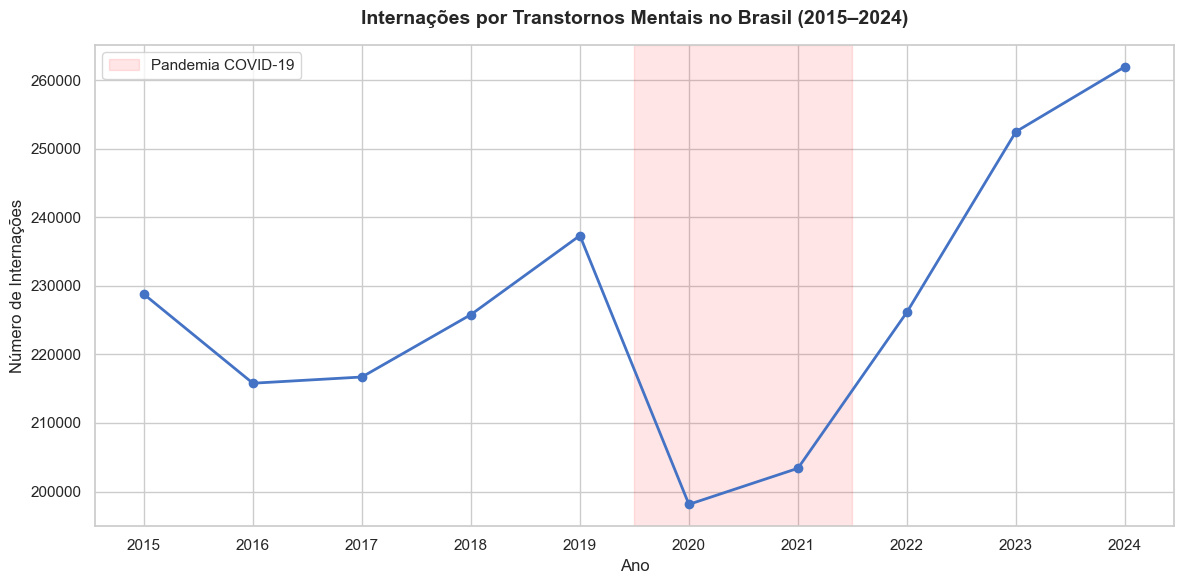

In [12]:
# Gráfico Visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_long["ano"], df_long["internacoes"],
        marker="o", color="#4472C4", linewidth=2)

ax.set_title("Internações por Transtornos Mentais no Brasil (2015–2024)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Ano")
ax.set_ylabel("Número de Internações")

ax.axvspan(2019.5, 2021.5, alpha=0.1, color="red", label="Pandemia COVID-19")
ax.legend()

ax.xaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.savefig("../outputs/figures/01_serie_temporal_internacoes.png", dpi=150)
plt.show()

In [ ]:
# Carregar o novo arquivo com região (no arquivo que baixamos anteriormente não tinha a secção de "região", então foi feita uma nova busca no TabNet)
# Formatando a leitura do arquivo para facilitar o uso dos dados por região
df_regiao_raw = pd.read_csv("../data/raw/datasus_por_regiao.csv",
    sep=";",
    encoding="latin1",
    skiprows=4,      # pula as linhas 0 a 3 (metadados do TabNet)
    skipfooter=6,    # pula as últimas linhas com fonte e notas
    engine="python"  # obrigatório quando usa skipfooter
)

print(df_regiao_raw)
print(df_regiao_raw.columns.tolist())

                  Região   2015   2016   2017   2018   2019   2020   2021  \
0         1 Região Norte   7368   7568   7478   8011   7737   7367   8141   
1      2 Região Nordeste  40466  38110  36802  38065  40364  34880  37352   
2       3 Região Sudeste  90624  82235  81205  85122  93861  76259  77416   
3           4 Região Sul  70659  70325  73799  76356  76231  63525  64226   
4  5 Região Centro-Oeste  19659  17555  17417  18246  19137  16094  16251   

    2022   2023    2024   Total  
0   9107  10864   11159   84800  
1  40731  44023   44523  395316  
2  87016  99960  106338  880036  
3  71389  79003   81917  727430  
4  17918  18633   18018  178928  
['Região', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'Total']


In [ ]:
# Remover a linha "Total" (porque não é uma região)
df_regiao_raw = df_regiao_raw[df_regiao_raw["Região"].str.contains("Total", na=False)]

# Remover a coluna "Total" também (não é um ano)
df_regiao_raw = df_regiao_raw.drop(columns=["Total"], errors="ignore")

# Limpar o nome das regiões (remover o número do início: "1 Região Norte" → "Norte")
df_regiao_raw["Região"] = (
    df_regiao_raw["Região"]
    .str.replace(r"^\d+\s+Região\s+", "", regex=True)  # remove "1 Região "
    .str.strip()
)

print(df_regiao_raw)

         Região   2015   2016   2017   2018   2019   2020   2021   2022  \
0         Norte   7368   7568   7478   8011   7737   7367   8141   9107   
1      Nordeste  40466  38110  36802  38065  40364  34880  37352  40731   
2       Sudeste  90624  82235  81205  85122  93861  76259  77416  87016   
3           Sul  70659  70325  73799  76356  76231  63525  64226  71389   
4  Centro-Oeste  19659  17555  17417  18246  19137  16094  16251  17918   

    2023    2024  
0  10864   11159  
1  44023   44523  
2  99960  106338  
3  79003   81917  
4  18633   18018  


In [ ]:
# Convertendo de largo para longo (mesmo processo do DATASUS anterior)
colunas_ano = ["2015", "2016", "2017", "2018", "2019","2020", "2021", "2022", "2023", "2024"]

df_regiao_long = df_regiao_raw.melt(
    id_vars=["Região"],
    value_vars=colunas_ano,
    var_name="ano",
    value_name="internacoes"
)

df_regiao_long["ano"] = df_regiao_long["ano"].astype(int)
df_regiao_long["internacoes"] = pd.to_numeric(
    df_regiao_long["internacoes"], errors="coerce"
)

print(df_regiao_long.head(10))

         Região   ano  internacoes
0         Norte  2015         7368
1      Nordeste  2015        40466
2       Sudeste  2015        90624
3           Sul  2015        70659
4  Centro-Oeste  2015        19659
5         Norte  2016         7568
6      Nordeste  2016        38110
7       Sudeste  2016        82235
8           Sul  2016        70325
9  Centro-Oeste  2016        17555


C:\Users\desid\AppData\Local\Temp\ipykernel_19744\622415027.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


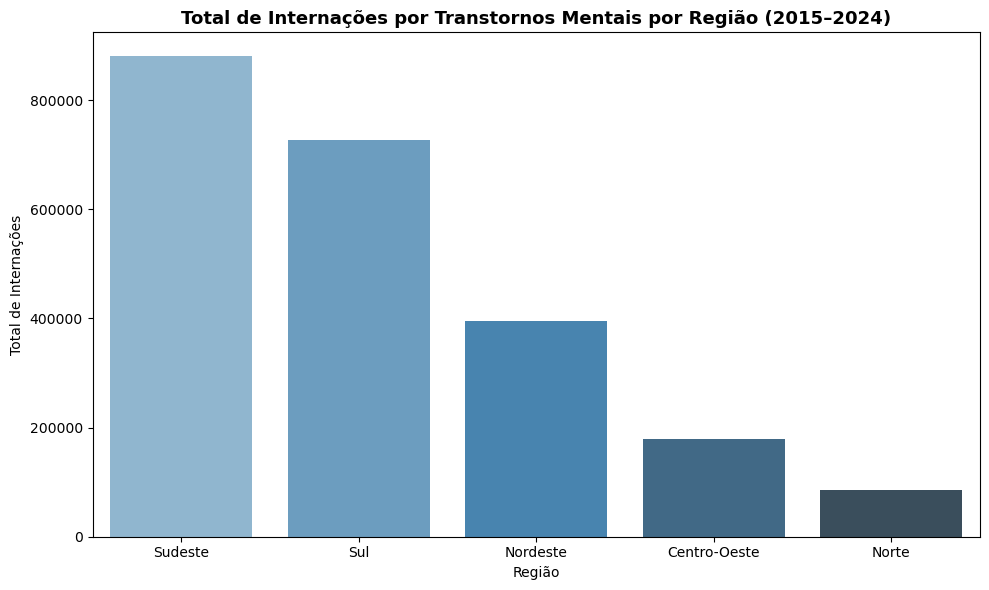

In [ ]:
# Total por região e gráfico
df_total_regiao = (df_regiao_long.groupby("Região")["internacoes"] .sum() .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=df_total_regiao.index,
    y=df_total_regiao.values,
    ax=ax,
    palette="Blues_d"
)

ax.set_title("Total de Internações por Transtornos Mentais por Região (2015–2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Região")
ax.set_ylabel("Total de Internações")

plt.tight_layout()
plt.savefig("../outputs/figures/02_internacoes_por_regiao.png", dpi=150)
plt.show()

In [ ]:
#Maracutaia para resolver problema de exportação para o Power BI (Oh deus)
import pandas as pd

# Recriar df_long a partir do arquivo limpo do DATASUS
df_limpo = pd.read_csv("../data/processed/datasus_internacoes_limpo.csv")

# Filtrar só transtornos mentais
df_mental = df_limpo[
    df_limpo.iloc[:, 0].str.contains("Transtornos mentais", case=False, na=False)
]

# Converter para formato longo
colunas_ano = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]

df_long = df_mental.melt(
    id_vars=[df_mental.columns[0]],
    value_vars=colunas_ano,
    var_name="ano",
    value_name="internacoes"
)
df_long["ano"] = df_long["ano"].astype(int)
df_long["internacoes"] = pd.to_numeric(df_long["internacoes"], errors="coerce")

print("df_long criado:", df_long.shape)

df_long criado: (10, 3)


In [ ]:
# Recriar df_regiao_long a partir do arquivo de regiões
df_regiao_raw = pd.read_csv(
    "../data/raw/datasus_por_regiao.csv",
    sep=";",
    encoding="latin1",
    skiprows=4,
    skipfooter=6,
    engine="python"
)

df_regiao_raw = df_regiao_raw[df_regiao_raw.iloc[:, 0].str.contains("Total", na=False)]
df_regiao_raw.iloc[:, 0] = (
    df_regiao_raw.iloc[:, 0]
    .str.replace(r"^\d+\s+Região\s+", "", regex=True)
    .str.strip()
)

df_regiao_long = df_regiao_raw.melt(
    id_vars=[df_regiao_raw.columns[0]],
    value_vars=colunas_ano,
    var_name="ano",
    value_name="internacoes"
)
df_regiao_long["internacoes"] = pd.to_numeric(df_regiao_long["internacoes"], errors="coerce")

print("df_regiao_long criado:", df_regiao_long.shape)

df_regiao_long criado: (50, 3)


In [17]:
# Agora exportar os dois
df_long.to_csv(
    "../data/processed/para_powerbi_serie_temporal.csv",
    index=False,
    encoding="utf-8-sig"
)

df_regiao_long.to_csv(
    "../data/processed/para_powerbi_regioes.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos exportados com sucesso!")

Arquivos exportados com sucesso!
